In [1]:
import matplotlib.pyplot as plt
import pandas as pd


dataset = pd.read_parquet("/Users/ryanaskin/Documents/datasci-challenge/renewables-dataset.parquet")

# Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

In [2]:
# These scale the already-computed solar_MWh and wind_MWh columns
a_s = 0.05  # solar matches (a_s x 100)% of the average yearly demand across EU
a_w = 0.10  # wind matches (a_w x 100)% of the average yearly demand across EU


# Compute scaled supply and residual load
dataset_residual = dataset.assign(
    solar_scaled_MWh=lambda df: a_s * df["solar_MWh"],
    wind_scaled_MWh=lambda df: a_w * df["wind_MWh"],
    supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
    residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
)[
    [
        "Time",
        "ID",
        "solar_scaled_MWh",
        "wind_scaled_MWh",
        "demand_MWh",
        "supply_scaled_MWh",
        "residual_MWh",
    ]
]

# Optional: inspect the result
print(dataset_residual.head())


                       Time ID  solar_scaled_MWh  wind_scaled_MWh  demand_MWh  \
0 2012-01-01 00:00:00+00:00  1               0.0         1.830164     75.6549   
1 2012-01-01 00:00:00+00:00  2               0.0         1.239282    557.8868   
2 2012-01-01 00:00:00+00:00  3               0.0         1.371017     15.5237   
3 2012-01-01 00:00:00+00:00  4               0.0         1.564818      8.6425   
4 2012-01-01 00:00:00+00:00  5               0.0         0.410738     85.3649   

   supply_scaled_MWh  residual_MWh  
0           1.830164     73.824736  
1           1.239282    556.647518  
2           1.371017     14.152683  
3           1.564818      7.077682  
4           0.410738     84.954162  


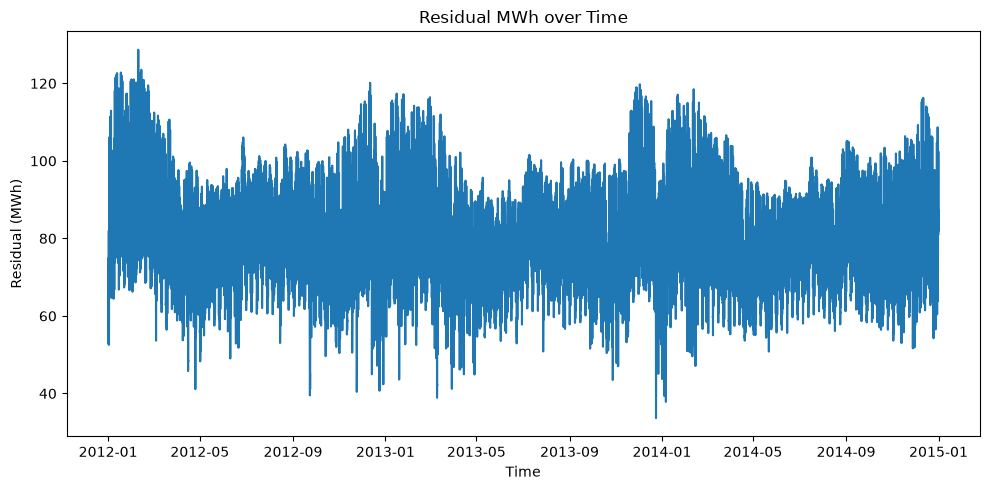

In [6]:
subset_station = dataset_residual.loc[dataset_residual["ID"] == "1"].drop(columns="ID")

plt.figure(figsize=(10, 5))
plt.plot(subset_station["Time"], subset_station["residual_MWh"])
plt.xlabel("Time")
plt.ylabel("Residual (MWh)")
plt.title("Residual MWh over Time")
plt.tight_layout()
plt.show()

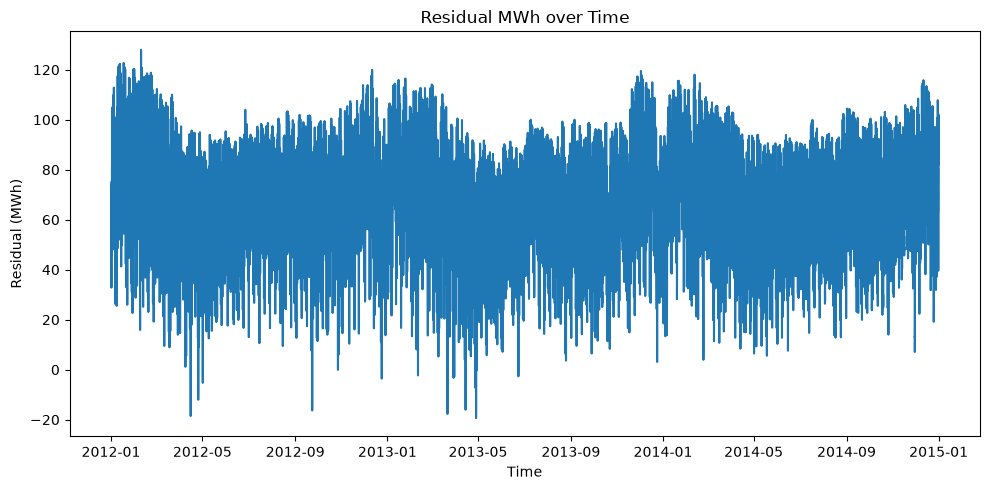

In [8]:
subset_station = dataset_residual.loc[dataset_residual["ID"] == "1"].drop(columns="ID")

plt.figure(figsize=(10, 5))
plt.plot(subset_station["Time"], subset_station["residual_MWh"])
plt.xlabel("Time")
plt.ylabel("Residual (MWh)")
plt.title("Residual MWh over Time")
plt.tight_layout()
plt.show()

In [ ]:
# 3. Filter to one node and to the dates 7-10 August 2013

# Important: ID is stored as a string
subset_station = dataset_residual.loc[dataset_residual["ID"] == "1"].drop(columns="ID")


mask = (
    (subset_station["Time"].dt.year == 2013)
    & (subset_station["Time"].dt.month == 8)
    & (subset_station["Time"].dt.day.isin([7, 8, 9, 10]))
)

subset_data = subset_station.loc[mask].melt(
    id_vars="Time",
    var_name="source",
    value_name="MWh",
)

# Optional: inspect filtered long-format data
print(subset_data.head())